In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


In [10]:
df=pd.read_csv('insurance.csv')

In [12]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [14]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


/tmp/ipykernel_596/3449268917.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["charges"],bins=20)


<Axes: xlabel='charges', ylabel='Density'>

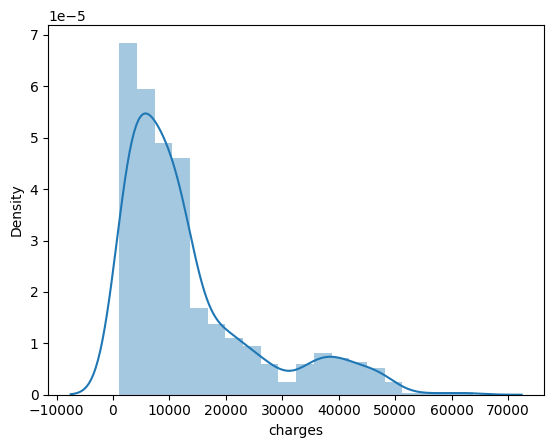

In [19]:
sns.distplot(df["charges"],bins=20)

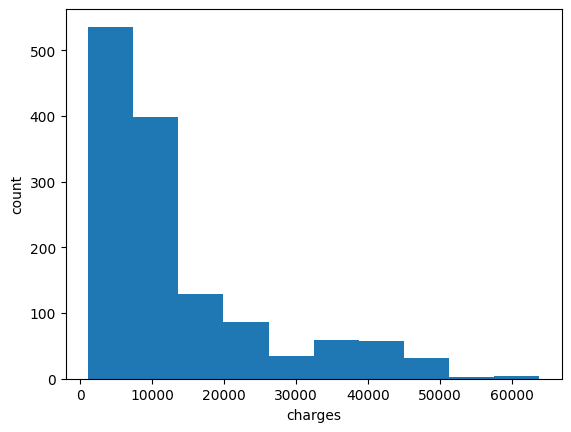

In [20]:
plt.xlabel('charges')
plt.ylabel('count')
plt.hist(df['charges']);

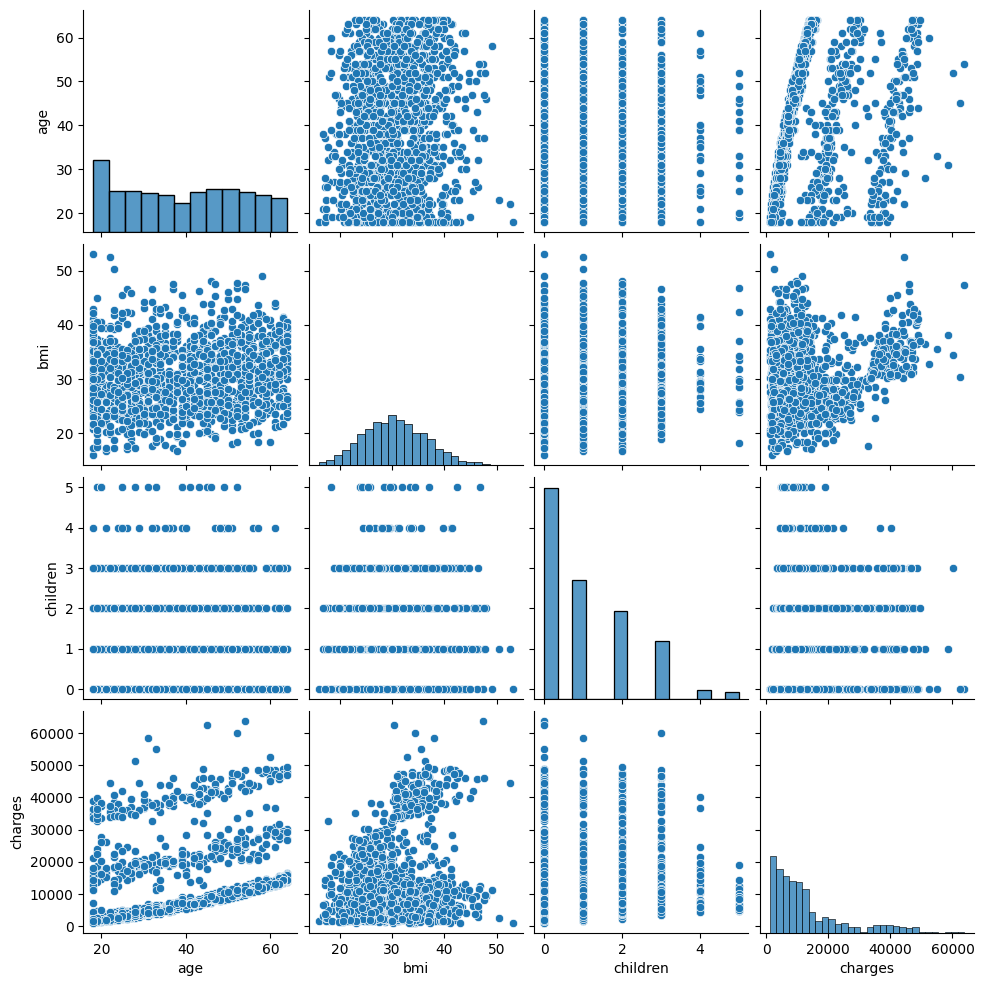

In [21]:
sns.pairplot(df)

In [29]:
from sklearn import preprocessing

df_categorical=df.select_dtypes(include=['object'])
df_categorical.head()

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest


In [31]:
le=preprocessing.LabelEncoder()
df_categorical=df_categorical.apply(le.fit_transform)
df_categorical.head()

,sex,smoker,region
0,0,1,3
1,1,0,2
2,1,0,2
3,1,0,1
4,1,0,1


In [32]:
df=df.drop(df_categorical.columns,axis=1)

In [34]:
df=pd.concat([df,df_categorical],axis=1)

In [36]:
df.head()

,age,bmi,children,charges,sex,smoker,region
0,19,27.900,0,16884.92400,0,1,3
1,18,33.770,1,1725.55230,1,0,2
2,28,33.000,3,4449.46200,1,0,2
3,33,22.705,0,21984.47061,1,0,1
4,32,28.880,0,3866.85520,1,0,1


In [38]:
target=df.pop('charges')
df['charges']=target
df.head()


,age,bmi,children,sex,smoker,region,charges
0,19,27.900,0,0,1,3,16884.92400
1,18,33.770,1,1,0,2,1725.55230
2,28,33.000,3,1,0,2,4449.46200
3,33,22.705,0,1,0,1,21984.47061
4,32,28.880,0,1,0,1,3866.85520


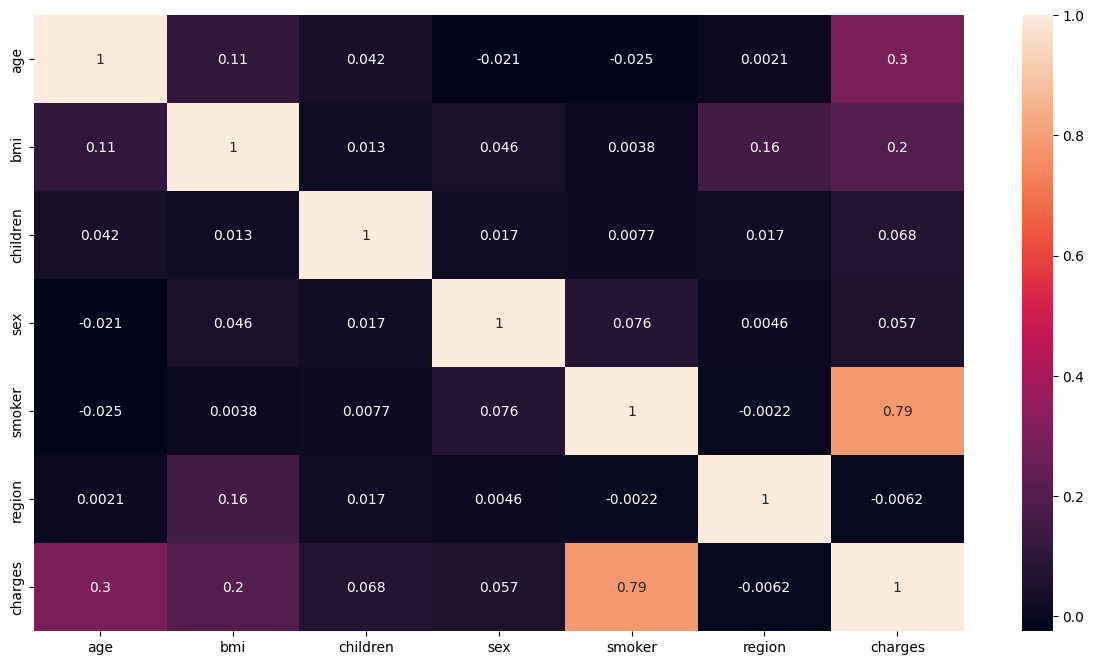

In [39]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(), annot=True);

In [43]:
x=df.drop('charges',axis=1)
y=df['charges']

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.4,random_state=23)

In [48]:
lm=LinearRegression()

In [49]:
lm.fit(x_train,y_train)

LinearRegression()

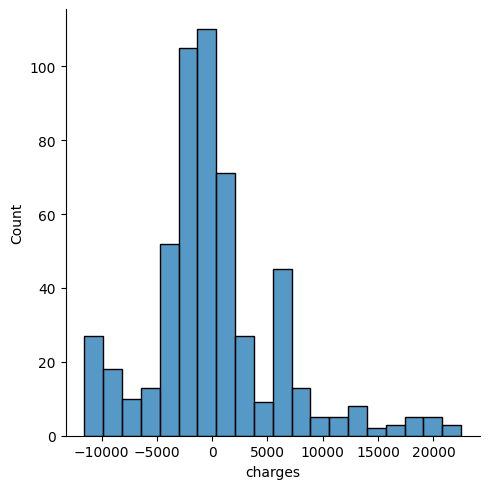

In [53]:
sns.displot((y_test-prediction),bins=20)

In [55]:
lm.coef_

array([  247.81865071,   347.7838562 ,   626.55962707,   -54.00475062,
       24163.07032295,  -551.96519991])

In [58]:
lm.intercept_

np.float64(-11917.162104145931)

In [60]:
Real_Values = np.array(y_test)
Real_Values

array([13041.921  ,  5031.26955, 20984.0936 , 25656.57526,  3201.24515,
        7256.7231 , 41999.52   , 12404.8791 , 14001.1338 , 47269.854  ,
        2597.779  , 29330.98315,  2741.948  , 14256.1928 ,  6238.298  ,
        4746.344  ,  6652.5288 ,  2250.8352 , 41676.0811 , 39836.519  ,
       47928.03   ,  7650.77375,  6457.8434 , 11837.16   , 42211.1382 ,
        4837.5823 ,  4894.7533 , 36219.40545,  2201.0971 ,  8556.907  ,
       12644.589  ,  2473.3341 ,  4032.2407 , 13224.693  ,  5584.3057 ,
       19350.3689 , 12479.70895,  7261.741  , 30284.64294,  3537.703  ,
       11165.41765, 40003.33225, 10264.4421 , 21098.55405, 11554.2236 ,
        9880.068  ,  4340.4409 ,  4435.0942 , 26140.3603 , 27375.90478,
       11674.13   ,  6338.0756 ,  9724.53   ,  3443.064  ,  3490.5491 ,
       10579.711  , 10602.385  ,  8527.532  ,  7325.0482 , 33475.81715,
       35491.64   ,  4076.497  ,  1137.4697 ,  3943.5954 ,  2523.1695 ,
        5469.0066 , 14133.03775,  1141.4451 ,  4133.64165, 26125

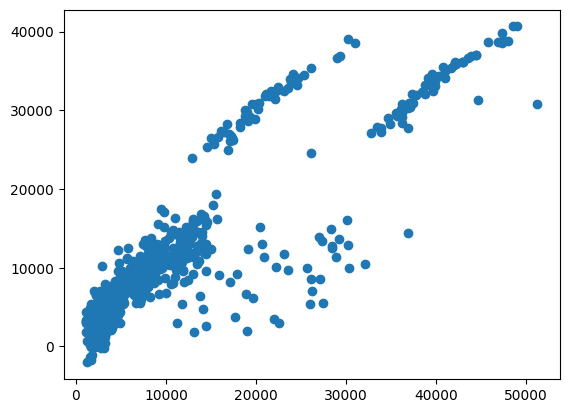

In [62]:
plt.scatter(y_test,prediction)

In [64]:
metrics.mean_absolute_error(y_test,prediction)

4149.803762582866

In [66]:
np.sqrt(metrics.mean_squared_error(y_test,prediction))

np.float64(5946.898554913689)

In [68]:
metrics.mean_squared_error(y_test,prediction)

35365602.42243452

In [69]:
metrics.r2_score(y_test,prediction)

0.746734642783226